In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
import warnings

import ast

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [113]:
portfolio = pd.read_csv('../data/portfolio.csv')
profile = pd.read_csv('../data/profile.csv')
transcript = pd.read_csv('../data/transcript.csv')

---

In [114]:
# 데이터 타입 date형식으로 변환
profile["became_member_on"] = pd.to_datetime(profile["became_member_on"], format="%Y%m%d")


# channels마다 파생변수 생성
portfolio['web'] = portfolio['channels'].astype(str).str.contains('web').astype(int)
portfolio['email'] = portfolio['channels'].astype(str).str.contains('email').astype(int)
portfolio['mobile'] = portfolio['channels'].astype(str).str.contains('mobile').astype(int)
portfolio['social'] = portfolio['channels'].astype(str).str.contains('social').astype(int)

# 기존 channels 컬럼 제거
portfolio = portfolio.drop('channels', axis=1)

In [115]:
# 딕셔너리처럼 생긴 문자열을 진짜 딕셔너리로 변환
transcript['value'] = transcript['value'].apply(ast.literal_eval)

# 딕셔너리의 키 -> 새로운 컬럼
value_df = pd.DataFrame(transcript['value'].tolist())
transcript = pd.concat([transcript, value_df], axis=1)

# offer id를 offer_id로 컬럼명 통일
transcript['offer_id'] = transcript['offer_id'].fillna(transcript['offer id'])

# offer id 컬럼 제거
transcript = transcript.drop('offer id', axis=1)

# value 컬럼 제거
transcript = transcript.drop('value', axis=1)

In [116]:
# profile의 필요없는 Unnamed:0 컬럼 제거
profile = profile.drop('Unnamed: 0', axis=1)

# transcript 기준으로 profile 데이터를 Left Join
merged_df = pd.merge(transcript, profile, left_on='person', right_on='id', how='left')

# 필요 없는 id 컬럼(person과 중복)은 버리기
merged_df = merged_df.drop(columns='id')

In [117]:
# 결측치 처리

# gender의 결측치 'Unknown'으로 채우기 
merged_df['gender'] = merged_df['gender'].fillna('Unknown')


# age의 118을 결측치(NaN)로 바꿔주기 
merged_df['age'] = merged_df['age'].replace(118, np.nan)
# income은 이미 결측치(NaN) 상태

In [118]:
# portfolio 테이블도 병합

# portfolio 테이블의 필요없는 인덱스 컬럼 제거
portfolio = portfolio.drop('Unnamed: 0', axis=1)

all_merge_df = pd.merge(
    merged_df,
    portfolio,
    left_on='offer_id',
    right_on='id',
    how='left'
)

all_merge_df = all_merge_df.drop(columns='id')

# reward 컬럼명 변경(명확하게)
all_merge_df = all_merge_df.rename(columns={
    "reward_x": "transcript_reward",
    "reward_y": "portfolio_reward"
})

In [119]:
# offer_id 이름 변경 (쿠폰명_difficulty_reward_duration)
portfolio['offer_name'] = (
    portfolio['offer_type'] + '_' + 
    portfolio['difficulty'].astype(str) + '_' + 
    portfolio['reward'].astype(str) + '_' + 
    portfolio['duration'].astype(str)
)
# id : key, offer_name : value
offer_name_dict = portfolio.set_index('id')['offer_name'].to_dict()
all_merge_df['offer_id'] = all_merge_df['offer_id'].map(offer_name_dict)


# 사람(person)별로 먼저 묶고, 그 안에서 시간(time) 순서대로 오름차순 정렬
all_merge_df = all_merge_df.sort_values(by=['person', 'time', 'Unnamed: 0']) # - Unnamed: 0 순서 추가

In [120]:
# 무엇을 위해 하는 코드인가? -> informational이 아닌 completed와 amount 경우만 선택하는 과정

# 조건 1: 쿠폰 타입이 bogo 이거나(in) discount 인 것
cond_offers = all_merge_df['offer_type'].isin(['bogo', 'discount'])

# 조건 2: 이벤트 종류가 transaction(결제) 인 것
cond_transactions = all_merge_df['event'] == 'transaction'

# 위 두 조건 중 하나라도 만족하는(|) 데이터만 쏙 뽑아서 덮어씌우기
target_df = all_merge_df[cond_offers | cond_transactions].copy()

# 잘 걸러졌는지 눈으로 확인해보기
print(target_df['offer_type'].value_counts(dropna=False))
print(target_df['event'].value_counts(dropna=False))
display(target_df.head())
display(target_df.shape)

offer_type
NaN         138953
bogo         71617
discount     69898
Name: count, dtype: int64
event
transaction        138953
offer received      61042
offer viewed        46894
offer completed     33579
Name: count, dtype: int64


,Unnamed: 0,person,event,time,amount,offer_id,transcript_reward,gender,age,became_member_on,income,portfolio_reward,difficulty,duration,offer_type,web,email,mobile,social
89291,89291,0009655768c64bdeb2e877511632db8f,transaction,228,22.16,NaN,NaN,M,33.0,2017-04-21,72000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153401,153401,0009655768c64bdeb2e877511632db8f,offer received,408,NaN,bogo_5_5_5,NaN,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
168412,168412,0009655768c64bdeb2e877511632db8f,transaction,414,8.57,NaN,NaN,M,33.0,2017-04-21,72000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168413,168413,0009655768c64bdeb2e877511632db8f,offer completed,414,NaN,bogo_5_5_5,5.0,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
187554,187554,0009655768c64bdeb2e877511632db8f,offer viewed,456,NaN,bogo_5_5_5,NaN,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0


(280468, 19)

In [121]:
# person당 offer_id를 하나의 행으로 설정하여, 흩어진 고객 행동의 순서를 보기 편하게 해주는 "피벗테이블 생성 코드"

# 1. 피벗을 돌릴 '쿠폰 이력서' 데이터만 빼내기
offers_df = target_df[target_df['event'] != 'transaction'].copy()

# 2. 안전한 금고에 보관할 '순수 영수증' 데이터만 빼내기
transactions_df = target_df[target_df['event'] == 'transaction'].copy()

print(f"피벗할 쿠폰 데이터: {len(offers_df)} 줄")
print(f"금고에 보관한 영수증: {len(transactions_df)} 줄")

피벗할 쿠폰 데이터: 141515 줄
금고에 보관한 영수증: 138953 줄


In [122]:
# 1. 시간 순서대로 예쁘게 줄 세우기
offers_df = offers_df.sort_values(['person', 'offer_id', 'time'])

# 2. 'received' 이벤트가 등장할 때마다 1, 아니면 0인 깃발(Flag) 만들기
offers_df['is_received'] = (offers_df['event'] == 'offer received').astype(int)

# 3. 사람과 쿠폰 단위로 묶어서, 깃발을 누적해서 더하기 (Cumsum)
offers_df['offer_cycle'] = offers_df.groupby(['person', 'offer_id'])['is_received'].cumsum()

# 4. 피벗 돌리기
pivot_df = offers_df.pivot_table(
    index=['person', 'offer_id', 'offer_cycle'],
    columns='event',
    values='time',
    aggfunc='min'
).reset_index()

pivot_df.columns.name = None
pivot_df = pivot_df[['person', 'offer_id', 'offer_cycle', 'offer received', 'offer viewed', 'offer completed']]

# reward 따로 뽑아서 merge
reward_df = offers_df[offers_df['event'] == 'offer completed'][['person', 'offer_id', 'offer_cycle', 'transcript_reward']]
pivot_df = pivot_df.merge(reward_df, on=['person', 'offer_id', 'offer_cycle'], how='left')

# ✅ portfolio 정보 붙이기
pivot_df = pivot_df.merge(
    portfolio[['offer_name', 'offer_type', 'difficulty', 'reward', 'duration', 'web', 'email', 'mobile', 'social']],
    left_on='offer_id',
    right_on='offer_name',
    how='left'
).drop(columns='offer_name')

# ✅ profile 정보 붙이기
pivot_df = pivot_df.merge(
    profile[['id', 'gender', 'age', 'became_member_on', 'income']],
    left_on='person',
    right_on='id',
    how='left'
).drop(columns='id')

display(pivot_df.head())
display(pivot_df.shape)

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,transcript_reward,offer_type,difficulty,reward,duration,web,email,mobile,social,gender,age,became_member_on,income
0,0009655768c64bdeb2e877511632db8f,bogo_5_5_5,1,408.0,456.0,414.0,5.0,bogo,5,5,5,1,1,1,1,M,33,2017-04-21,72000.0
1,0009655768c64bdeb2e877511632db8f,discount_10_2_10,1,504.0,540.0,528.0,2.0,discount,10,2,10,1,1,1,1,M,33,2017-04-21,72000.0
2,0009655768c64bdeb2e877511632db8f,discount_10_2_7,1,576.0,NaN,576.0,2.0,discount,10,2,7,1,1,1,0,M,33,2017-04-21,72000.0
3,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,1,168.0,216.0,NaN,NaN,bogo,5,5,5,1,1,1,1,NaN,118,2018-04-25,NaN
4,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,2,576.0,630.0,NaN,NaN,bogo,5,5,5,1,1,1,1,NaN,118,2018-04-25,NaN


(61520, 19)

In [123]:
# 1. 원본에서 offer_id와 offer_type 짝꿍 사전 만들기
offer_dict = offers_df[['offer_id', 'offer_type']].drop_duplicates().set_index('offer_id')['offer_type'].to_dict()

# 2. 피벗 테이블의 offer_id를 보고, 임시로 쿠폰 타입(bogo, discount)을 가져오기
temp_offer_type = pivot_df['offer_id'].map(offer_dict)

# 3. [핵심] 기존 숫자였던 'offer_cycle' 컬럼 위에 곧바로 덮어쓰기! 
pivot_df['offer_cycle'] = temp_offer_type.str.capitalize() + '_' + pivot_df['offer_cycle'].astype(str)


In [124]:
# 피벗테이블에 amount 붙이기

# 1. 금고(transactions_df)에서 영수증 알맹이만 꺼내기
transactions_df = transactions_df[['person', 'time', 'amount']]

# 2. 피벗 테이블(pivot_df)에 영수증(receipts) 1:1 도킹하기!
final_df = pivot_df.merge(
    transactions_df,
    left_on=['person', 'offer completed'],
    right_on=['person', 'time'],
    how='left'
)

# 3. 도킹 끝나고 쓸모없어진 'time' 기둥 버리기
final_df = final_df.drop(columns=['time'])

display(final_df.head())
display(final_df.shape)


,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,transcript_reward,offer_type,difficulty,reward,duration,web,email,mobile,social,gender,age,became_member_on,income,amount
0,0009655768c64bdeb2e877511632db8f,bogo_5_5_5,Bogo_1,408.0,456.0,414.0,5.0,bogo,5,5,5,1,1,1,1,M,33,2017-04-21,72000.0,8.57
1,0009655768c64bdeb2e877511632db8f,discount_10_2_10,Discount_1,504.0,540.0,528.0,2.0,discount,10,2,10,1,1,1,1,M,33,2017-04-21,72000.0,14.11
2,0009655768c64bdeb2e877511632db8f,discount_10_2_7,Discount_1,576.0,NaN,576.0,2.0,discount,10,2,7,1,1,1,0,M,33,2017-04-21,72000.0,10.27
3,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_1,168.0,216.0,NaN,NaN,bogo,5,5,5,1,1,1,1,NaN,118,2018-04-25,NaN,NaN
4,00116118485d4dfda04fdbaba9a87b5c,bogo_5_5_5,Bogo_2,576.0,630.0,NaN,NaN,bogo,5,5,5,1,1,1,1,NaN,118,2018-04-25,NaN,NaN


(61520, 20)

In [125]:
final_df.to_csv('../data/final_df.csv', index=False)

---

# xxx

In [126]:
amount_by_offer = (
    final_df[final_df['amount'].notna()]
    .groupby('offer_id')
    .agg(
        total_amount=('amount', 'sum'),
        total_reward=('transcript_reward', 'sum')
    )
    .reset_index()
)

# 실제 매출 = amount - reward
amount_by_offer['net_revenue'] = amount_by_offer['total_amount'] - amount_by_offer['total_reward']
amount_by_offer = amount_by_offer.sort_values('total_amount', ascending=False)

# 총합 행 추가
total_row = pd.DataFrame([{
    'offer_id': '합계',
    'total_amount': amount_by_offer['total_amount'].sum(),
    'total_reward': amount_by_offer['total_reward'].sum(),
    'net_revenue': amount_by_offer['net_revenue'].sum()
}])
amount_by_offer = pd.concat([amount_by_offer, total_row], ignore_index=True)

display(amount_by_offer)

,offer_id,total_amount,total_reward,net_revenue
0,discount_10_2_10,97883.54,10634.0,87249.54
1,discount_7_3_7,90530.90,15468.0,75062.90
2,bogo_10_10_7,88106.63,36880.0,51226.63
3,discount_20_5_10,87900.50,17100.0,70800.50
4,bogo_5_5_5,83592.17,21480.0,62112.17
5,discount_10_2_7,82671.14,8034.0,74637.14
6,bogo_10_10_5,79283.59,33310.0,45973.59
7,bogo_5_5_7,77911.04,21770.0,56141.04
8,합계,687879.51,164676.0,523203.51


In [127]:
# # 합계 행 제외하고 시각화
# plot_df = amount_by_offer[amount_by_offer['offer_id'] != '합계'].copy()

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# fig.suptitle('쿠폰별 매출 성과', fontsize=16, fontweight='bold')

# x = range(len(plot_df))
# width = 0.35

# # 왼쪽: total_amount vs net_revenue 비교 막대그래프
# axes[0].bar([i - width/2 for i in x], plot_df['total_amount'], width, label='총 결제액', color='steelblue', alpha=0.8)
# axes[0].bar([i + width/2 for i in x], plot_df['net_revenue'], width, label='순매출', color='tomato', alpha=0.8)
# axes[0].set_title('쿠폰별 총 결제액 vs 순매출')
# axes[0].set_xticks(x)
# axes[0].set_xticklabels(plot_df['offer_id'], rotation=45, ha='right')
# axes[0].set_ylabel('금액 ($)')
# axes[0].legend()

# # 오른쪽: total_reward (리워드 비용) 막대그래프
# axes[1].bar(x, plot_df['total_reward'], color='orange', alpha=0.8)
# axes[1].set_title('쿠폰별 리워드 지급 비용')
# axes[1].set_xticks(x)
# axes[1].set_xticklabels(plot_df['offer_id'], rotation=45, ha='right')
# axes[1].set_ylabel('리워드 비용 ($)')

# plt.tight_layout()
# plt.show()

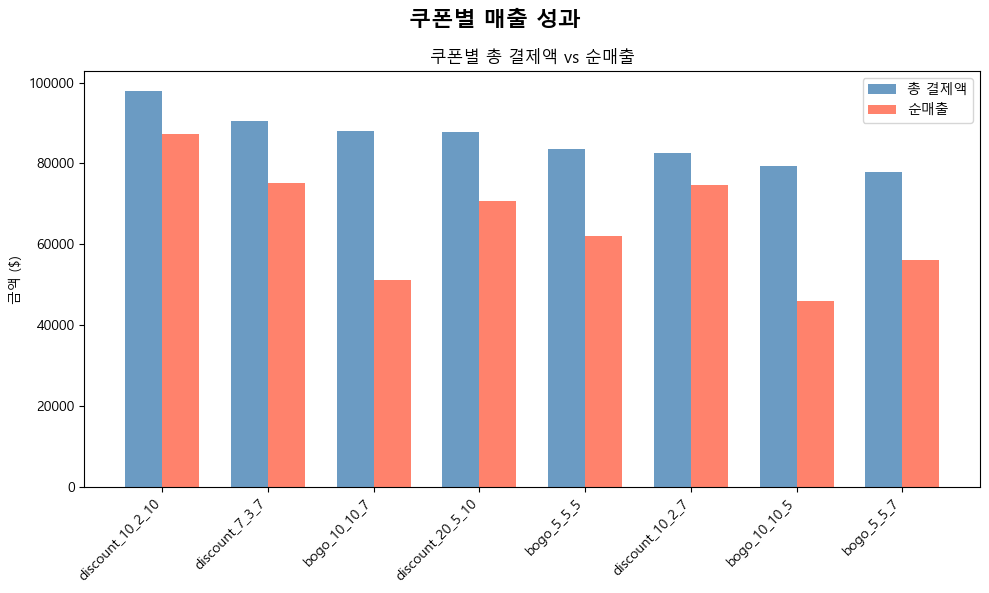

In [128]:
plot_df = amount_by_offer[amount_by_offer['offer_id'] != '합계'].copy()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle('쿠폰별 매출 성과', fontsize=16, fontweight='bold')

x = range(len(plot_df))
width = 0.35

ax.bar([i - width/2 for i in x], plot_df['total_amount'], width, label='총 결제액', color='steelblue', alpha=0.8)
ax.bar([i + width/2 for i in x], plot_df['net_revenue'], width, label='순매출', color='tomato', alpha=0.8)
ax.set_title('쿠폰별 총 결제액 vs 순매출')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['offer_id'], rotation=45, ha='right')
ax.set_ylabel('금액 ($)')
ax.legend()

plt.tight_layout()
plt.show()

---

# 정상 흐름

In [129]:
# 정상 흐름 필터링: received <= viewed <= completed (모두 존재해야 함)
normal_flow_df = final_df[
    final_df['offer received'].notna() &
    final_df['offer viewed'].notna() &
    final_df['offer completed'].notna() &
    (final_df['offer received'] <= final_df['offer viewed']) &
    (final_df['offer viewed'] <= final_df['offer completed'])
].copy()

display(normal_flow_df.head())
display(normal_flow_df.shape)

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,transcript_reward,offer_type,difficulty,reward,duration,web,email,mobile,social,gender,age,became_member_on,income,amount
5,0011e0d4e6b944f998e987f904e8c1e5,bogo_5_5_7,Bogo_1,504.0,516.0,576.0,5.0,bogo,5,5,7,1,1,1,0,O,40,2018-01-09,57000.0,22.05
6,0011e0d4e6b944f998e987f904e8c1e5,discount_20_5_10,Discount_1,408.0,432.0,576.0,5.0,discount,20,5,10,1,1,0,0,O,40,2018-01-09,57000.0,22.05
7,0011e0d4e6b944f998e987f904e8c1e5,discount_7_3_7,Discount_1,168.0,186.0,252.0,3.0,discount,7,3,7,1,1,1,1,O,40,2018-01-09,57000.0,11.93
8,0020c2b971eb4e9188eac86d93036a77,bogo_10_10_5,Bogo_1,408.0,426.0,510.0,10.0,bogo,10,10,5,1,1,1,1,F,59,2016-03-04,90000.0,17.24
10,0020c2b971eb4e9188eac86d93036a77,discount_10_2_10,Discount_1,0.0,12.0,54.0,2.0,discount,10,2,10,1,1,1,1,F,59,2016-03-04,90000.0,17.63


(23519, 20)

In [130]:
# 정상 흐름 데이터 기준으로 집계
normal_amount_by_offer = (
    normal_flow_df[normal_flow_df['amount'].notna()]
    .groupby('offer_id')
    .agg(
        total_amount=('amount', 'sum'),
        total_reward=('transcript_reward', 'sum')
    )
    .reset_index()
)
normal_amount_by_offer['net_revenue'] = normal_amount_by_offer['total_amount'] - normal_amount_by_offer['total_reward']
normal_amount_by_offer = normal_amount_by_offer.sort_values('total_amount', ascending=False)

# 총합 행 추가
total_row = pd.DataFrame([{
    'offer_id': '합계',
    'total_amount': normal_amount_by_offer['total_amount'].sum(),
    'total_reward': normal_amount_by_offer['total_reward'].sum(),
    'net_revenue': normal_amount_by_offer['net_revenue'].sum()
}])
normal_amount_by_offer = pd.concat([normal_amount_by_offer, total_row], ignore_index=True)

display(normal_amount_by_offer)

,offer_id,total_amount,total_reward,net_revenue
0,discount_10_2_10,83745.21,9286.0,74459.21
1,discount_7_3_7,74620.39,13164.0,61456.39
2,bogo_5_5_5,70345.30,17645.0,52700.30
3,bogo_10_10_5,65758.53,27590.0,38168.53
4,bogo_10_10_7,61939.08,26060.0,35879.08
5,discount_10_2_7,42748.89,4268.0,38480.89
6,bogo_5_5_7,37694.92,10620.0,27074.92
7,discount_20_5_10,35264.92,6680.0,28584.92
8,합계,472117.24,115313.0,356804.24


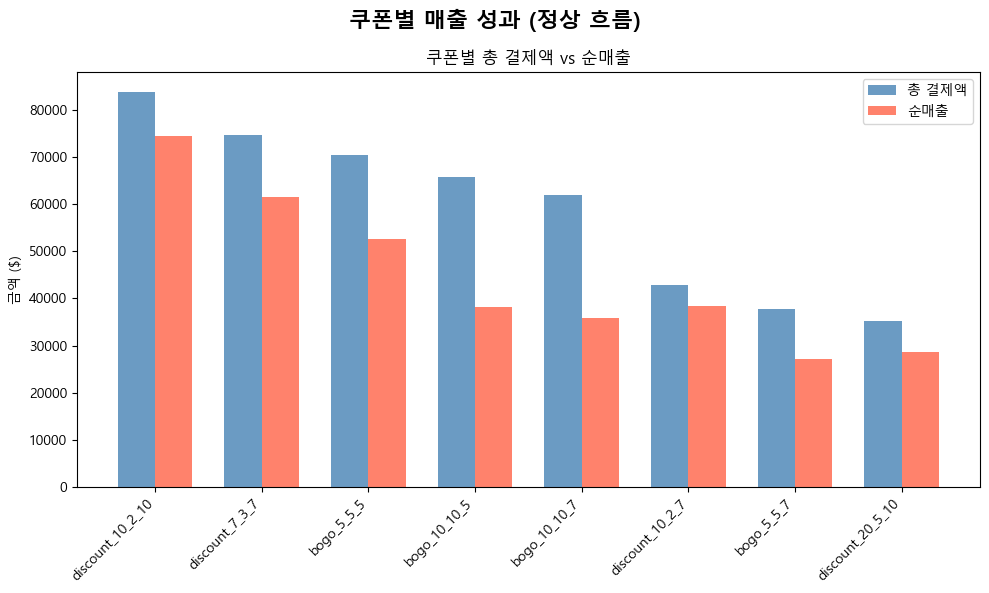

In [131]:
plot_df = normal_amount_by_offer[normal_amount_by_offer['offer_id'] != '합계'].copy()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle('쿠폰별 매출 성과 (정상 흐름)', fontsize=16, fontweight='bold')

x = range(len(plot_df))
width = 0.35

ax.bar([i - width/2 for i in x], plot_df['total_amount'], width, label='총 결제액', color='steelblue', alpha=0.8)
ax.bar([i + width/2 for i in x], plot_df['net_revenue'], width, label='순매출', color='tomato', alpha=0.8)
ax.set_title('쿠폰별 총 결제액 vs 순매출')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['offer_id'], rotation=45, ha='right')
ax.set_ylabel('금액 ($)')
ax.legend()

plt.tight_layout()
plt.show()

---

In [132]:
!jupyter nbconvert --to markdown "04_event_v2.ipynb"

[NbConvertApp] Converting notebook 04_event_v2.ipynb to markdown
[NbConvertApp] Support files will be in 04_event_v2_files\
[NbConvertApp] Making directory 04_event_v2_files
[NbConvertApp] Writing 27977 bytes to 04_event_v2.md
